        log_return  volatility
regime                        
0         0.012939    0.017261
1        -0.014622    0.025742
2        -0.002371    0.012594


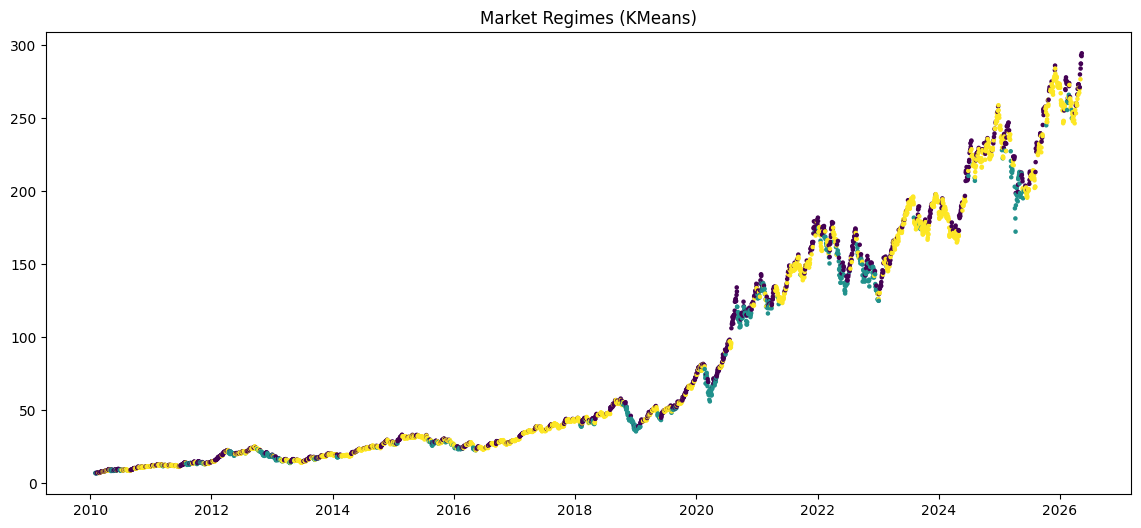

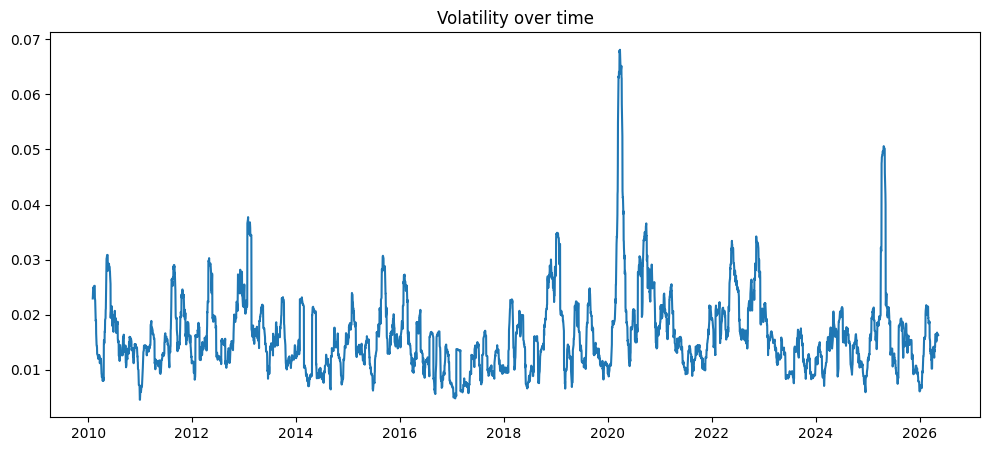

REGIME DETECTION DONE


In [1]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()

    if "close" in name:
        df["close"] = raw[col]

df = df.dropna()

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["volatility"] = df["log_return"].rolling(20).std()
df["momentum"] = df["close"] / df["close"].shift(10) - 1
df = df.dropna()

X = df[["log_return", "volatility", "momentum"]].copy()

# standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_regimes = 3

kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init=10)
df["regime"] = kmeans.fit_predict(X_scaled)

print(df.groupby("regime")[["log_return", "volatility"]].mean())

plt.figure(figsize=(14,6))
plt.scatter(df.index, df["close"], c=df["regime"], cmap="viridis", s=5)
plt.title("Market Regimes (KMeans)")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["volatility"])
plt.title("Volatility over time")
plt.show()

print("REGIME DETECTION DONE")